In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df=sns.load_dataset('mpg')
print(df)

      mpg  cylinders  displacement  horsepower  weight  acceleration  \
0    18.0          8         307.0       130.0    3504          12.0   
1    15.0          8         350.0       165.0    3693          11.5   
2    18.0          8         318.0       150.0    3436          11.0   
3    16.0          8         304.0       150.0    3433          12.0   
4    17.0          8         302.0       140.0    3449          10.5   
..    ...        ...           ...         ...     ...           ...   
393  27.0          4         140.0        86.0    2790          15.6   
394  44.0          4          97.0        52.0    2130          24.6   
395  32.0          4         135.0        84.0    2295          11.6   
396  28.0          4         120.0        79.0    2625          18.6   
397  31.0          4         119.0        82.0    2720          19.4   

     model_year  origin                       name  
0            70     usa  chevrolet chevelle malibu  
1            70     usa      

In [55]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object')

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


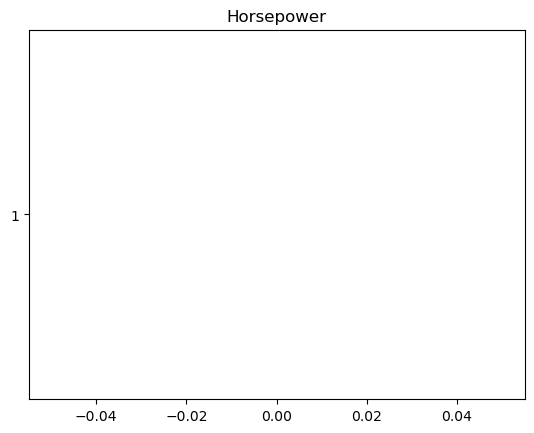

In [40]:
plt.boxplot(df['horsepower'],vert=False)
plt.title("Horsepower")
plt.show()

In [11]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [19]:
df[df['horsepower'].isnull()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
32,25.0,4,98.0,NaN,2046,19.0,71,usa,ford pinto
126,21.0,6,200.0,NaN,2875,17.0,74,usa,ford maverick
330,40.9,4,85.0,NaN,1835,17.3,80,europe,renault lecar deluxe
336,23.6,4,140.0,NaN,2905,14.3,80,usa,ford mustang cobra
354,34.5,4,100.0,NaN,2320,15.8,81,europe,renault 18i
374,23.0,4,151.0,NaN,3035,20.5,82,usa,amc concord dl


In [47]:
df['horsepower'].fillna(df['horsepower'].mean())

0      130.0
1      165.0
2      150.0
3      150.0
4      140.0
       ...  
393     86.0
394     52.0
395     84.0
396     79.0
397     82.0
Name: horsepower, Length: 398, dtype: float64

In [48]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.199187,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,95.000000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [50]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [51]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x2614a0ef110>,
 'caps': [<matplotlib.lines.Line2D at 0x2614a0ef390>,
 'boxes': [<matplotlib.lines.Line2D at 0x2614a0eefd0>],
 'medians': [<matplotlib.lines.Line2D at 0x2614a0ef610>],
 'fliers': [<matplotlib.lines.Line2D at 0x2614a0ef750>],
 'means': []}

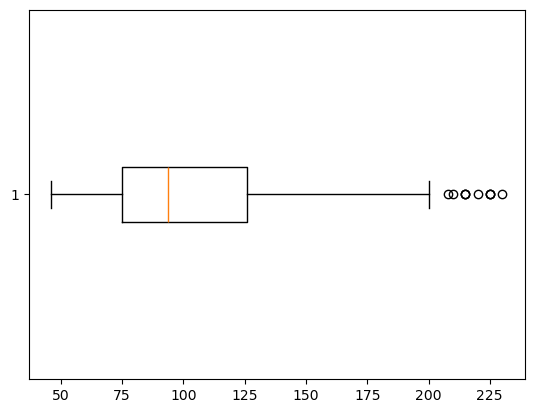

In [42]:
plt.boxplot(df['horsepower'].dropna(),vert=False)

In [43]:
def detect_outliers_iqr(df,horsepower):
 Q1=df[horsepower].quantile(0.25)
 Q3=df[horsepower].quantile(0.75)
 IQR=Q3-Q1
 lower_bound=Q1-1.5*IQR
 upper_bound=Q3+1.5*IQR
 outliers=df[(df[horsepower]<lower_bound)| (df[horsepower]>upper_bound)]
 return outliers,Q1,Q3,lower_bound,upper_bound

outliers,Q1,Q3,lower_bound,upper_bound=detect_outliers_iqr(df,'horsepower')

print("Q1:",Q1)
print("Q3:",Q3)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)

print("Number of outliers detected:",len(outliers))
outliers


Q1: 75.0
Q3: 126.0
lower_bound: -1.5
upper_bound: 202.5
Number of outliers detected: 10


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
13,14.0,8,455.0,225.0,3086,10.0,70,usa,buick estate wagon (sw)
25,10.0,8,360.0,215.0,4615,14.0,70,usa,ford f250
27,11.0,8,318.0,210.0,4382,13.5,70,usa,dodge d200
67,11.0,8,429.0,208.0,4633,11.0,72,usa,mercury marquis
94,13.0,8,440.0,215.0,4735,11.0,73,usa,chrysler new yorker brougham
95,12.0,8,455.0,225.0,4951,11.0,73,usa,buick electra 225 custom
116,16.0,8,400.0,230.0,4278,9.5,73,usa,pontiac grand prix


Outliers are somehow relatable to rest of the data of horsepower so, i have used mean to fill the null value

In [45]:
df['horsepower'].fillna(df['horsepower'].mean())

0      130.0
1      165.0
2      150.0
3      150.0
4      140.0
       ...  
393     86.0
394     52.0
395     84.0
396     79.0
397     82.0
Name: horsepower, Length: 398, dtype: float64

Q. Which car has the best fuel economy?

In [61]:
best_fueleconomy=df.sort_values(by='mpg',ascending=False)
best_fueleconomy[['name','mpg']].head(10)

,name,mpg
322,mazda glc,46.6
329,honda civic 1500 gl,44.6
325,vw rabbit c (diesel),44.3
394,vw pickup,44.0
326,vw dasher (diesel),43.4
244,volkswagen rabbit custom diesel,43.1
309,vw rabbit,41.5
330,renault lecar deluxe,40.9
324,datsun 210,40.8
247,datsun b210 gx,39.4


>mazda glc have best fuel economy as it travel 46.6 miles using 1 gallon of fuel

Q. Does a heavier car consume more fuel?

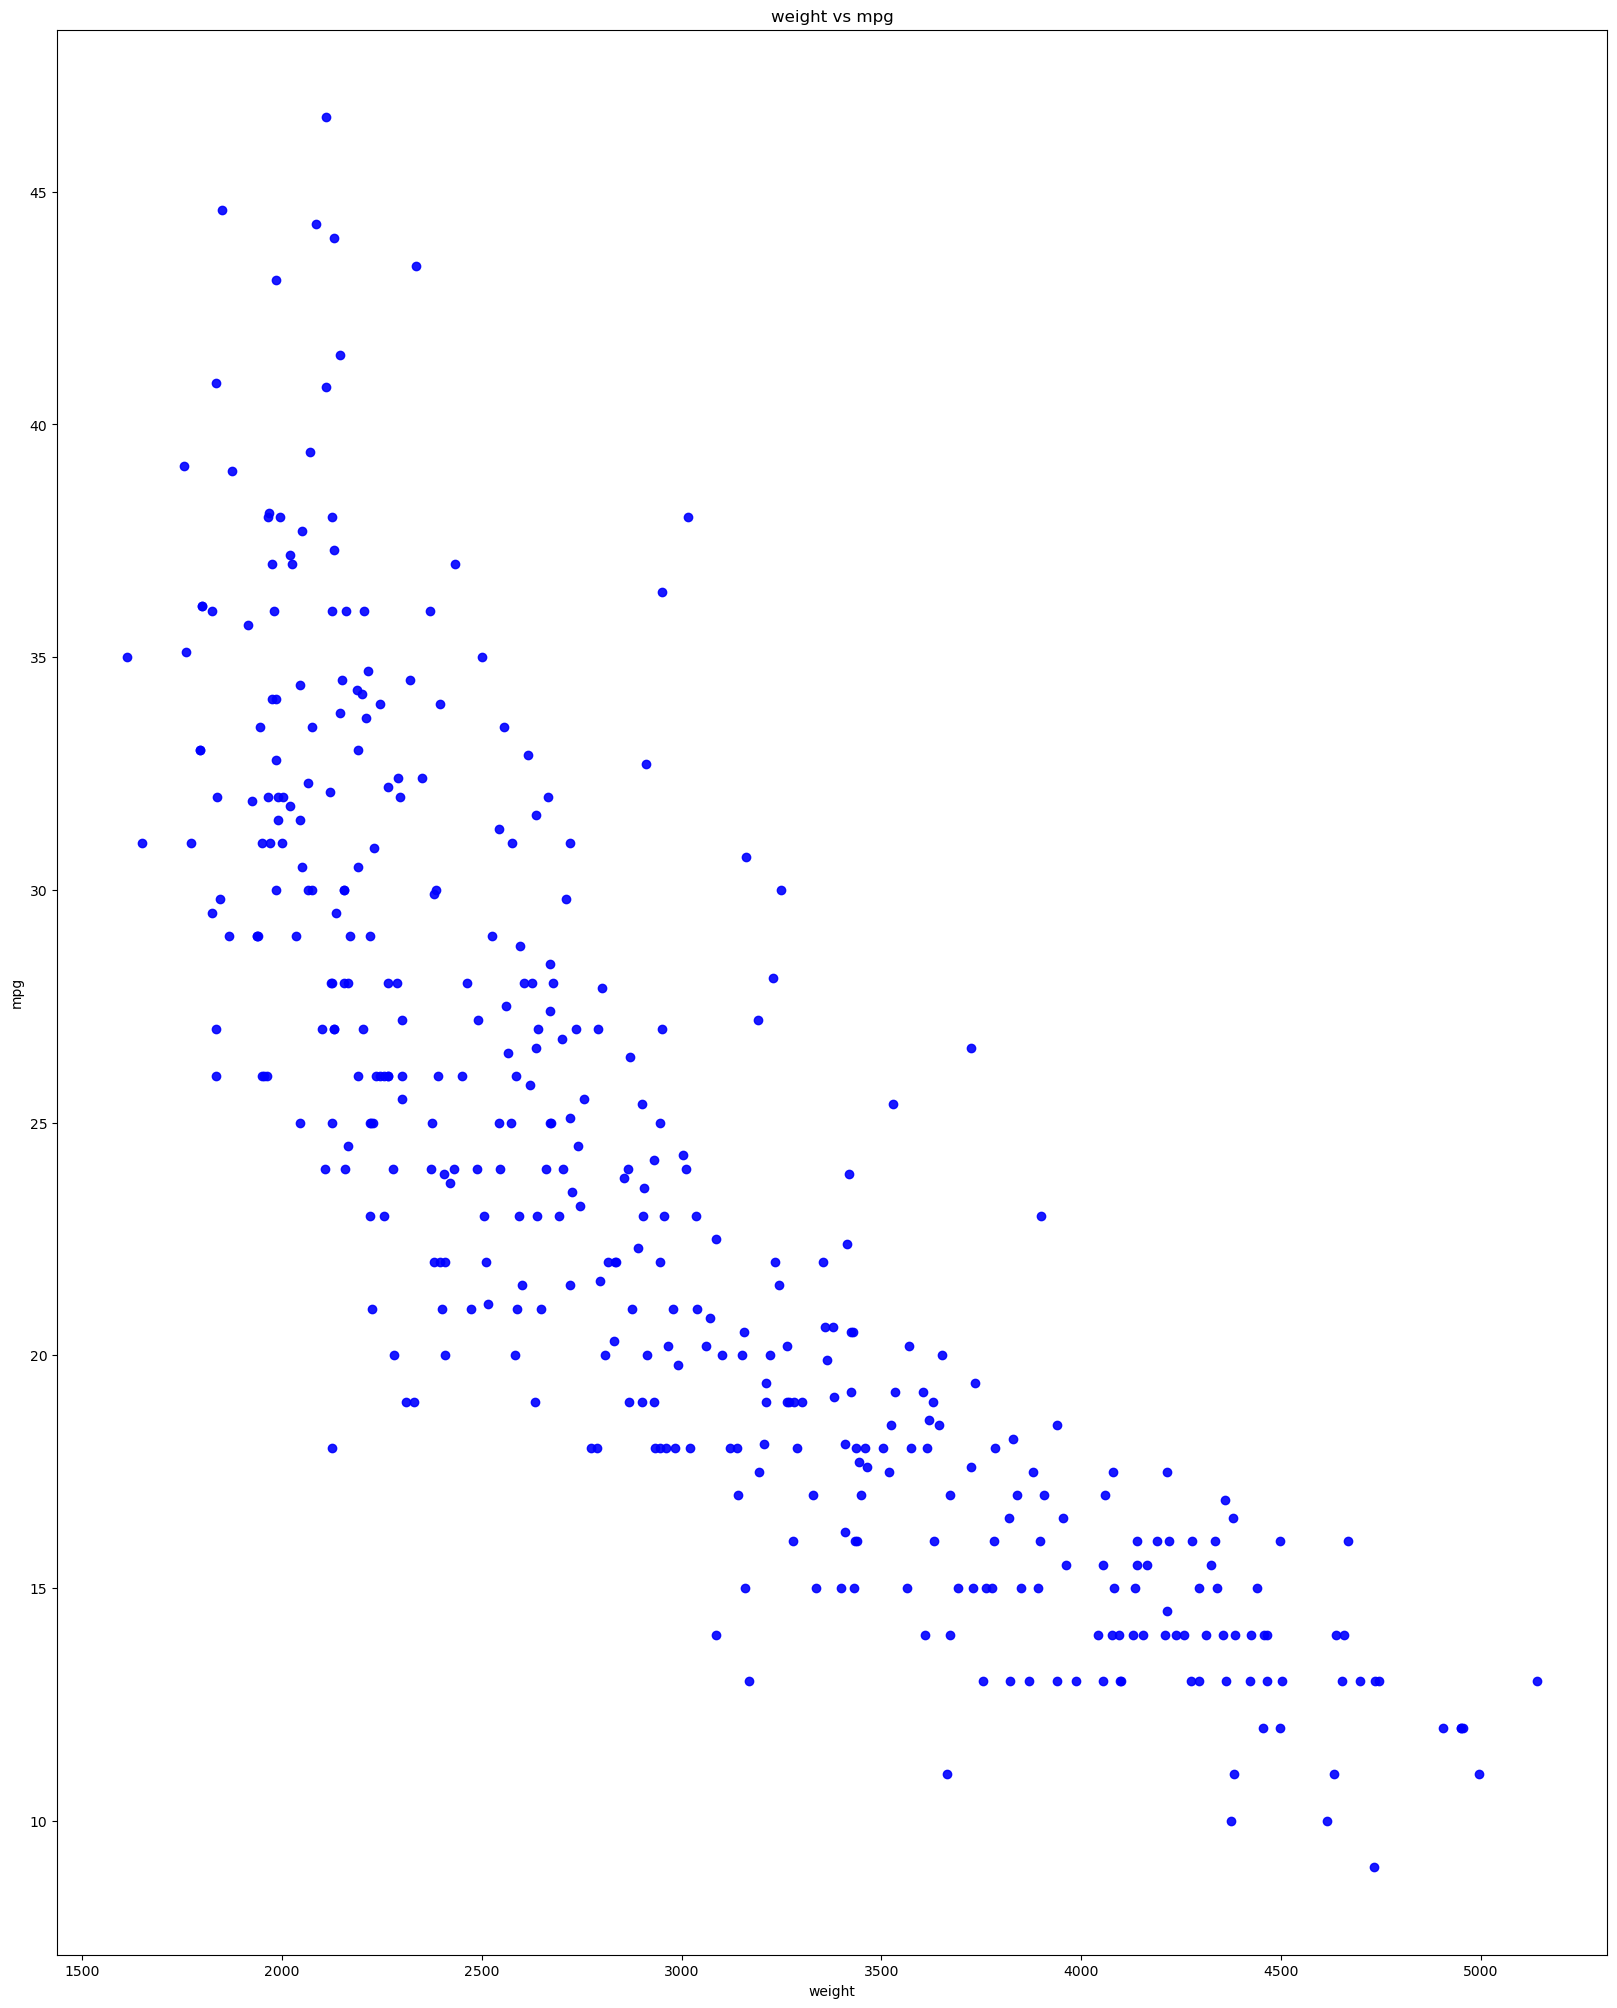

In [65]:
plt.figure(figsize=(20,25))
plt.scatter(df['weight'],df['mpg'],color='blue',alpha=0.9)
plt.xlabel('weight')
plt.ylabel('mpg')
plt.title('weight vs mpg')
plt.show()

The scatter plot shows there is strong negative relationship between weight of the car and its fuel efficiency as therefore heavier car consume more fuel than lighter one.

Q. Does horsepower affect fuel efficiency?

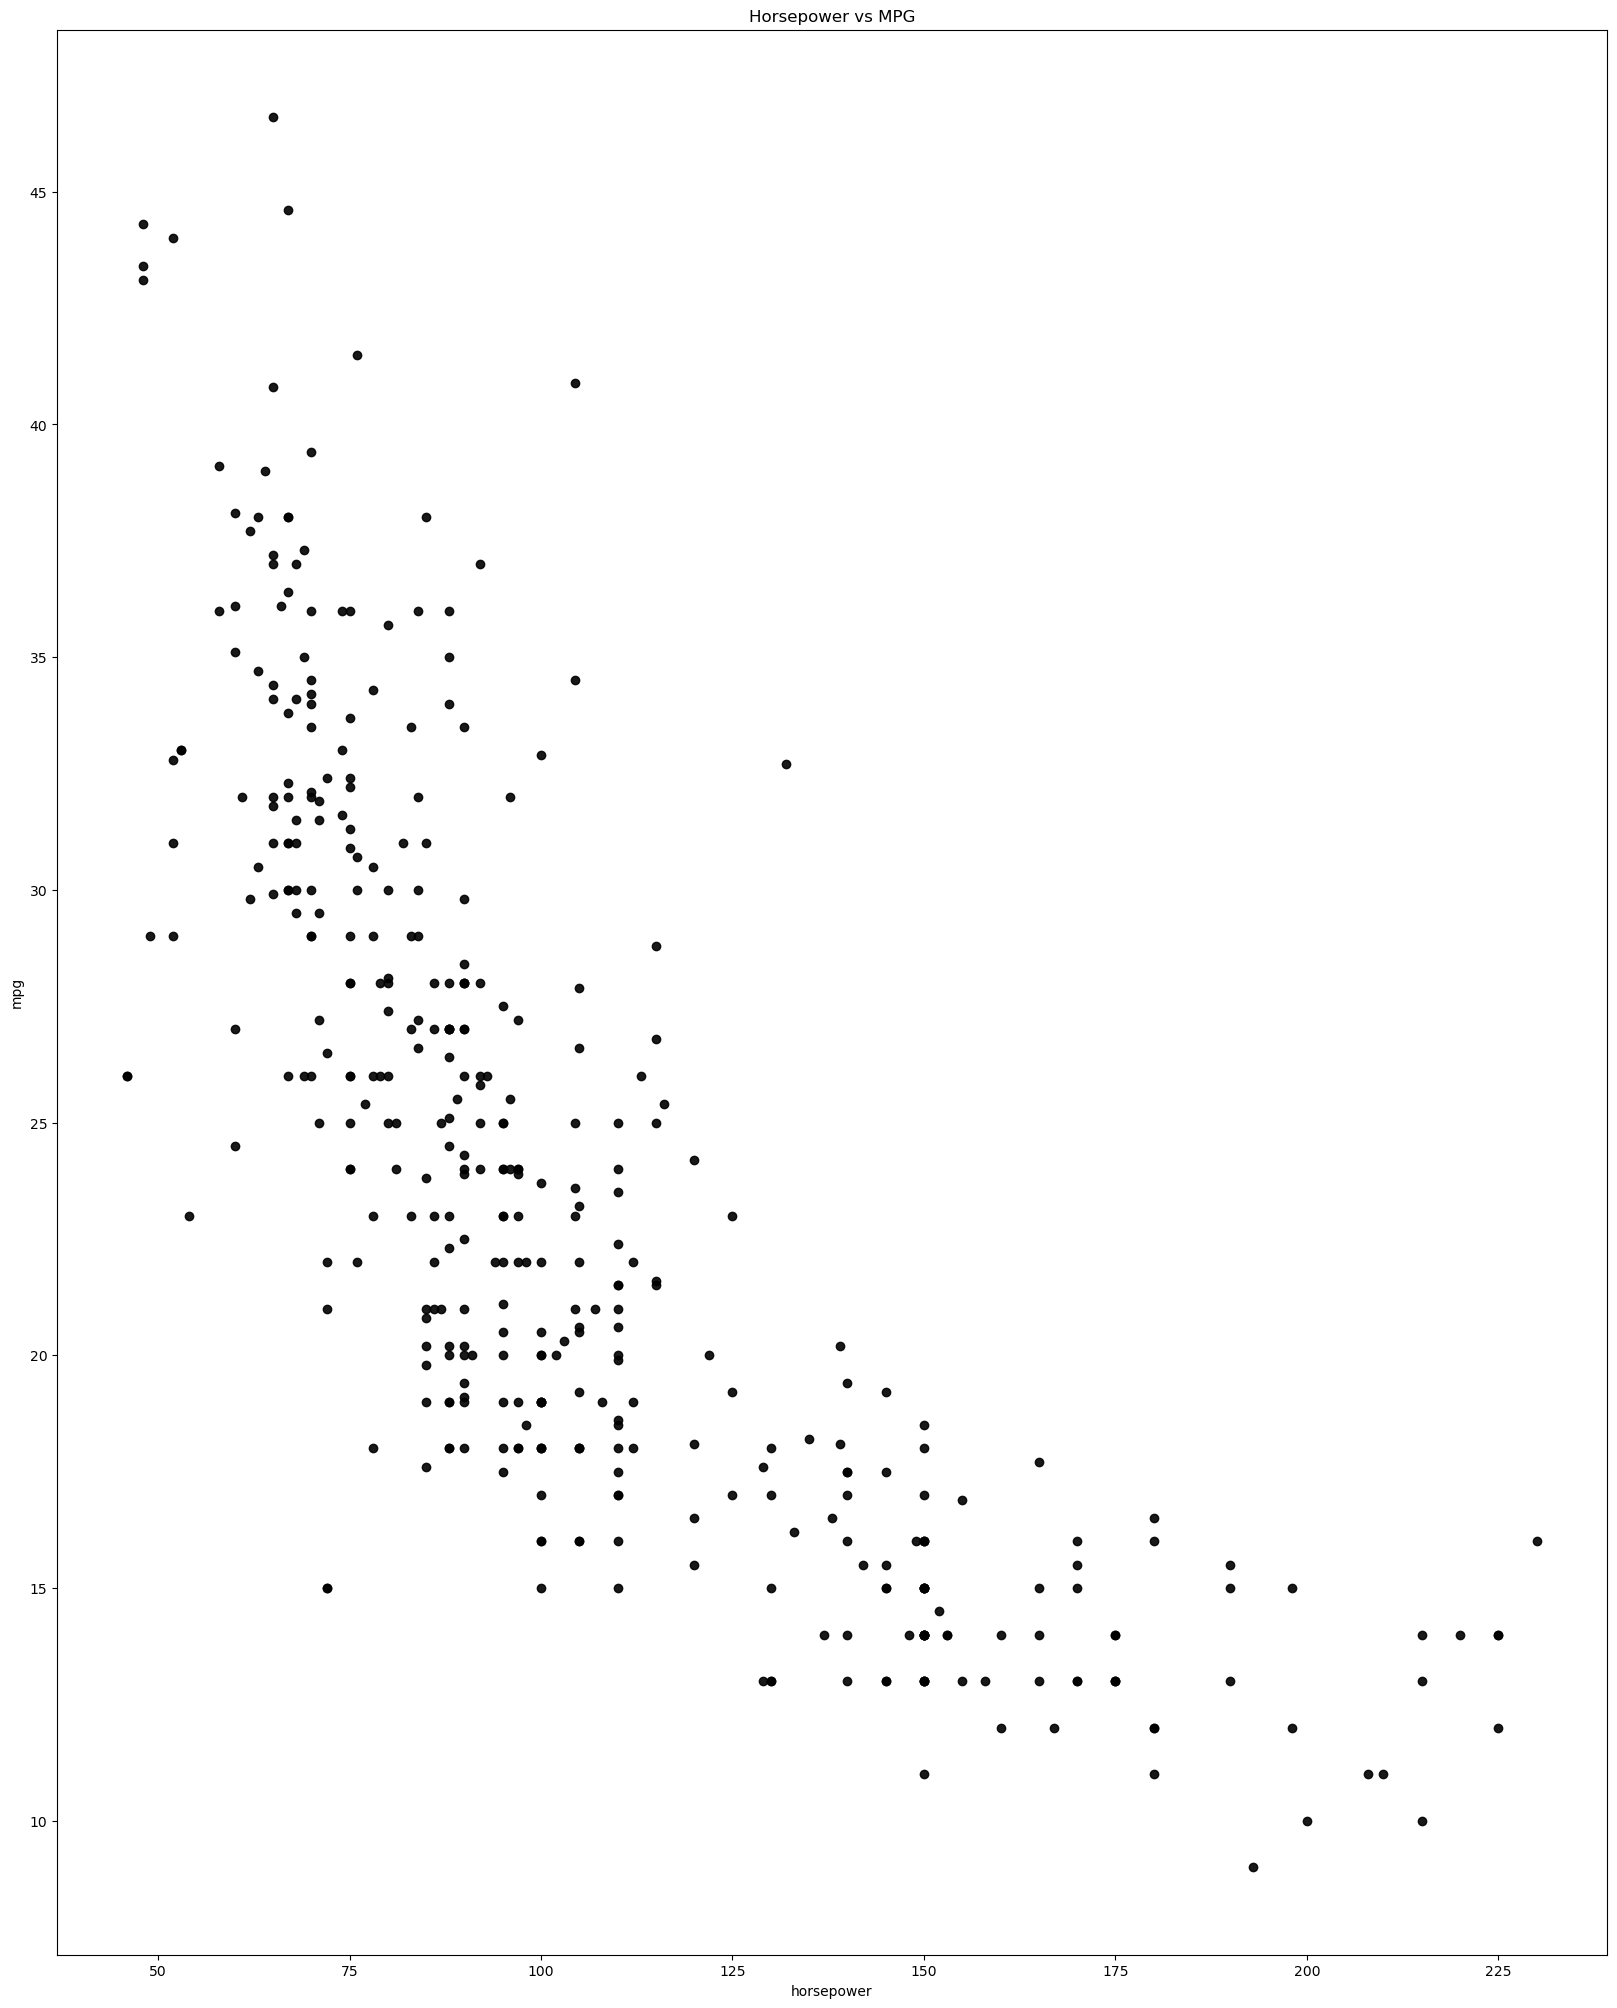

In [66]:
plt.figure(figsize=(20,25))
plt.scatter(df['horsepower'],df['mpg'],color='black',alpha=0.9)
plt.xlabel('horsepower')
plt.ylabel('mpg')
plt.title('Horsepower vs MPG')
plt.show()

The scatter plot shows there is strong negative relationship between horsepower of the car and its fuel efficiency as therefore horsepower of car consume more fuel than lighter one.

#Correlation between weight,fuel,mpg

In [75]:
df[['weight','mpg','horsepower']].corr()

,weight,mpg,horsepower
weight,1.000000,-0.831741,0.860574
mpg,-0.831741,1.000000,-0.771437
horsepower,0.860574,-0.771437,1.000000


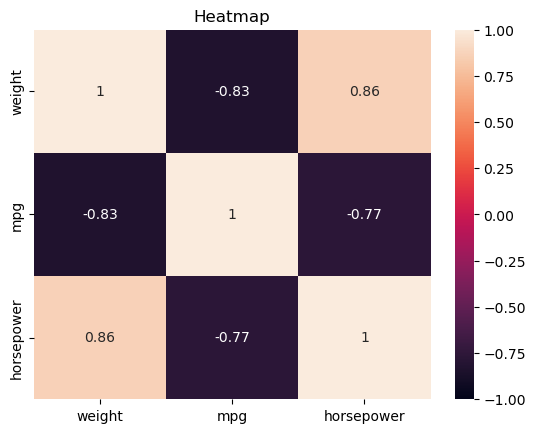

In [78]:
corr=df[['weight','mpg','horsepower']].corr()
sns.heatmap(corr,color='red',annot=True,vmin=-1,vmax=1)
plt.title('Heatmap')
plt.show()

Q.Which country makes the most fuel efficient cars?

In [79]:
df.groupby(df['origin'])['mpg'].mean().sort_values(ascending=False)

origin
japan     30.450633
europe    27.891429
usa       20.083534
Name: mpg, dtype: float64

japan makes the most fuel efficient cars

Q. Which car are the heaviest?


In [80]:
df.sort_values( by='weight',ascending=False)[['name','weight']].head(10)

,name,weight
44,pontiac safari (sw),5140
103,chevrolet impala,4997
42,dodge monaco (sw),4955
90,mercury marquis brougham,4952
95,buick electra 225 custom,4951
104,ford country,4906
43,ford country squire (sw),4746
94,chrysler new yorker brougham,4735
28,hi 1200d,4732
137,buick century luxus (sw),4699


Q.how many car belongs to each country?

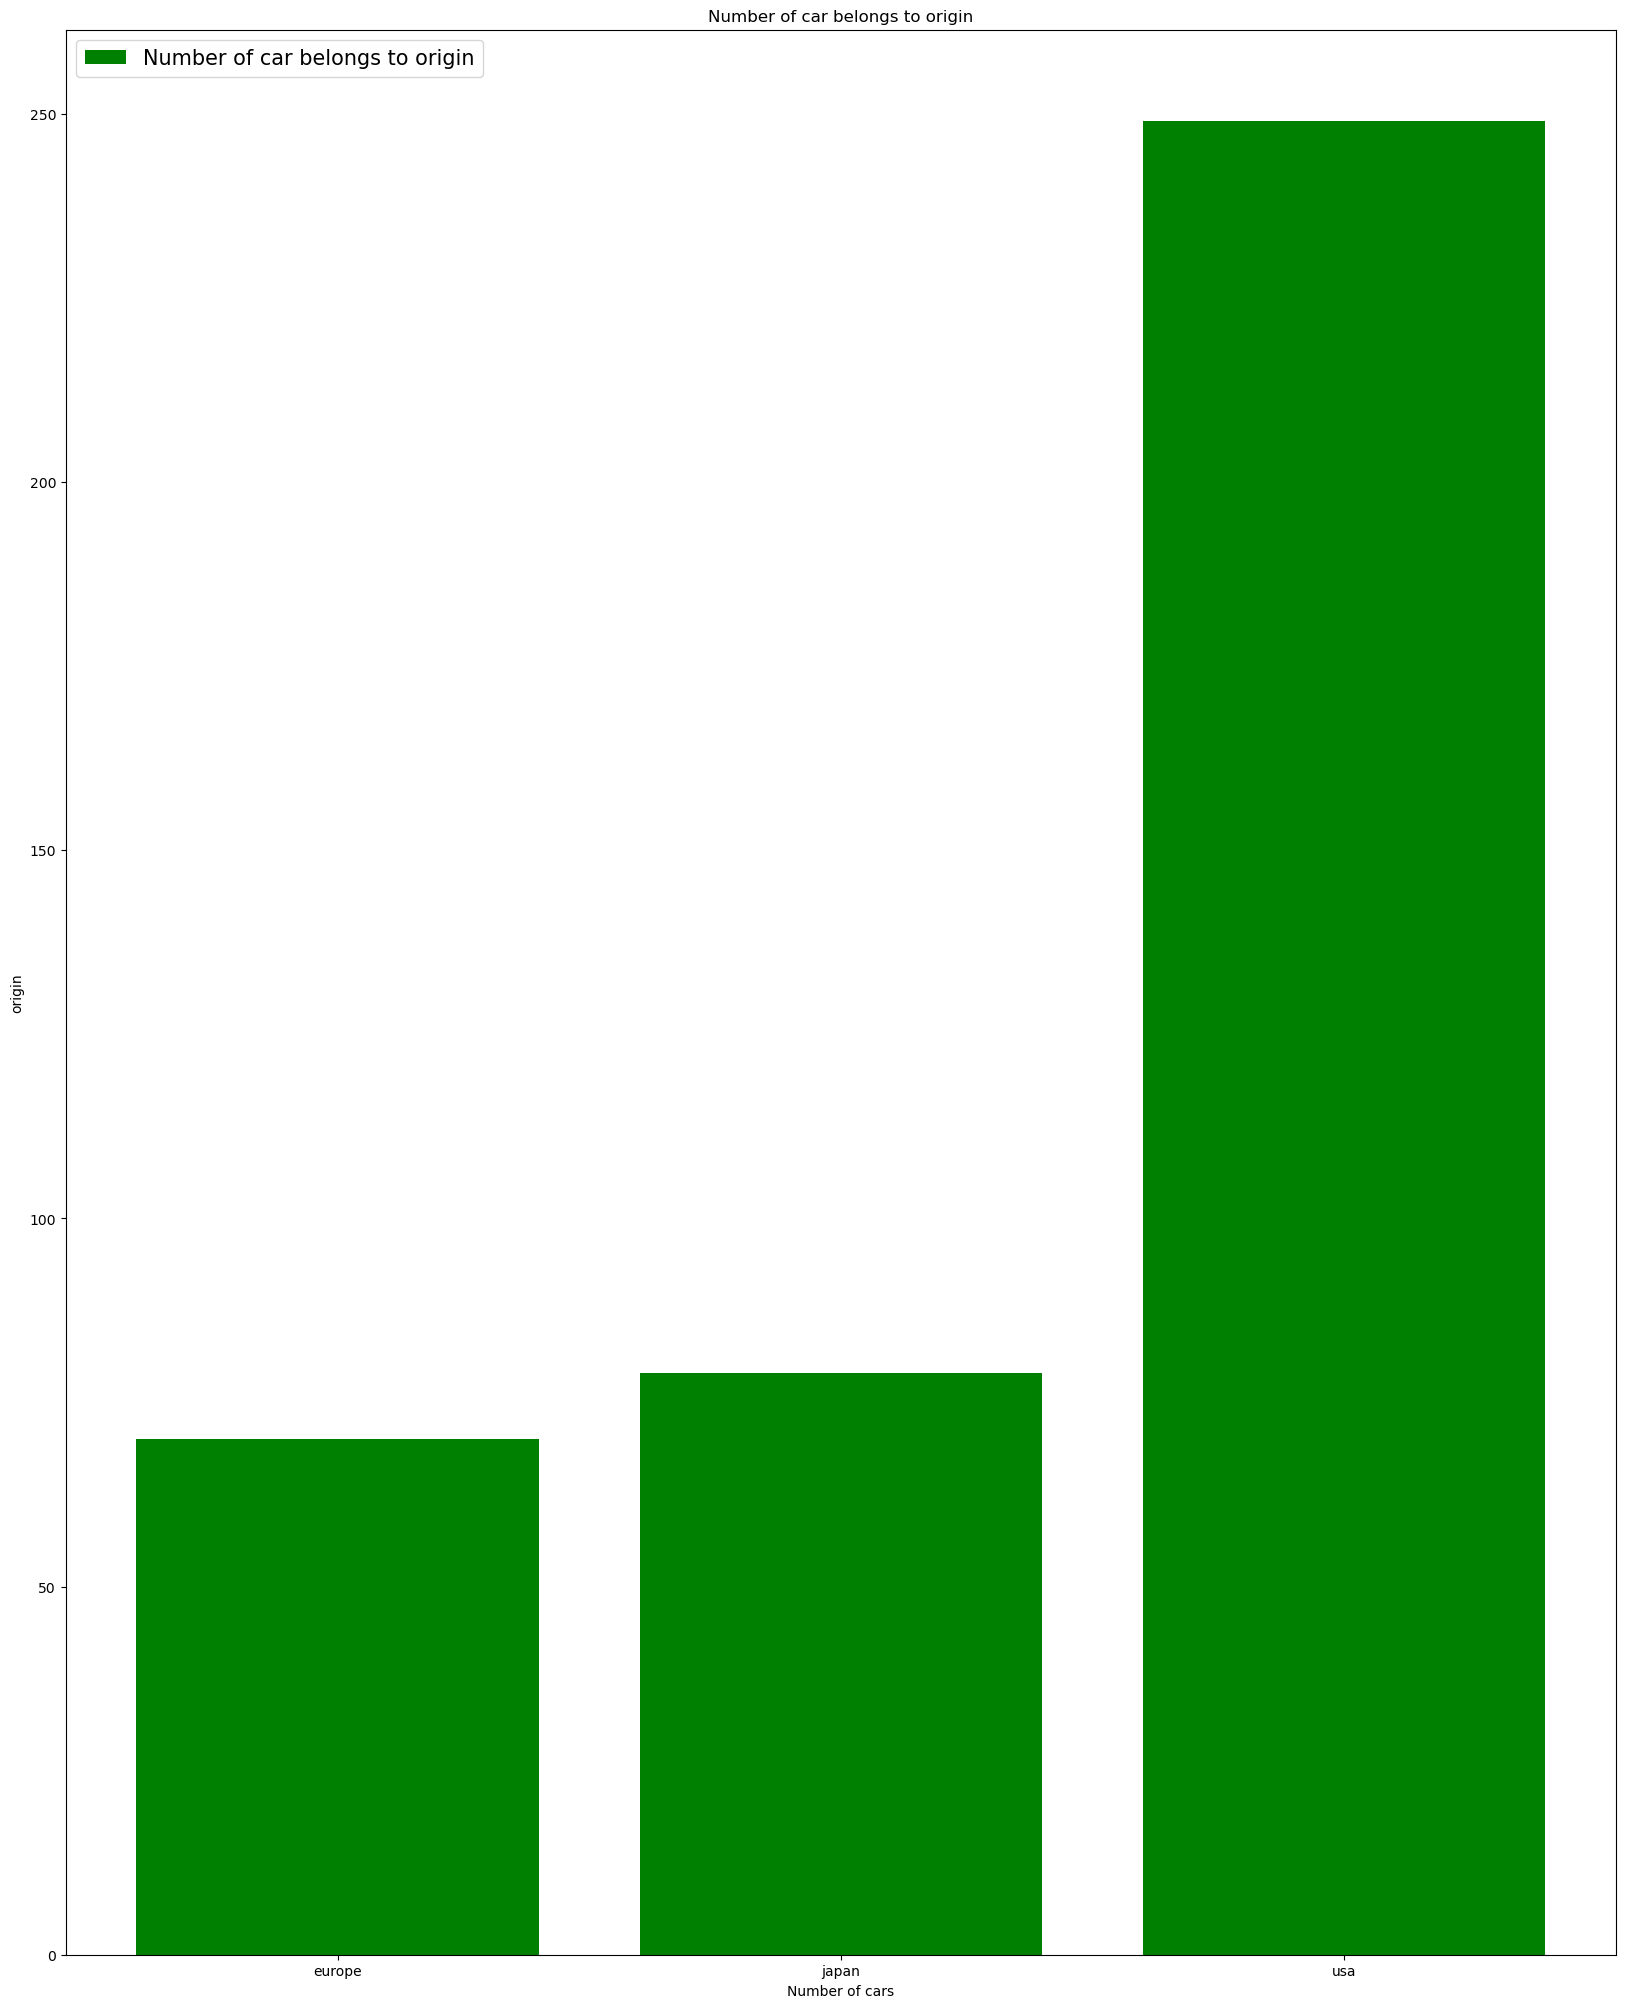

In [88]:
plt.figure(figsize=(20,25))
data=df.groupby('origin')['name'].count()
plt.bar(data.index,data.values,color='green',label='Number of car belongs to origin')
plt.xlabel('Number of cars')
plt.ylabel('origin')
plt.title('Number of car belongs to origin')
plt.legend(fontsize=15,loc='upper left')
plt.show()

Q.AVG horsepower by country?

In [90]:
df.groupby(df['origin'])['horsepower'].mean().sort_values(ascending=False)

origin
usa       118.814769
europe     81.241983
japan      79.835443
Name: horsepower, dtype: float64

USA uses high power engine cars as the result of which it has less fuel efficient market in comparison to Japan and Europe

In [91]:
df[df['name']=='mazda glc']

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
322,46.6,4,86.0,65.0,2110,17.9,80,japan,mazda glc


Conclusion:The mazda glc has the highest fuel efficiency in the dataset, with 46.6 MPG.There is a strong negative relationship between car weight and MPG, indicating that heavier cars generally have lower fuel efficiency.There is also a strong negative relationships between horsepower and MPG, showing that more powerful cars tend to consume more fuel. Weight and horsepower are strongly positively correlated, meaning heavier carss often have more powerful engines.Most car in the dataset are from USA followed by japan and Europe. The horsepower column contained 6 null value which were handled appropriately during data processing.only a small number of outliers were found in the horsepower columns, and they were not severe enough to significantly affect the analysis.

In [ ]:
df.to_csv('cleaned_mpg.csv',index=False)